# NomadOptima — Notebook 01: EDA de Datos de Entrada
## Fase 1: ¿De dónde vienen los datos?

**Objetivo:** Entender las 6 fuentes que alimentan el modelo, cuántas features
aporta cada una, qué ciudades tienen cobertura completa y qué correcciones
se aplicaron a los datos crudos antes del análisis.

**Dataset:** `city_features.csv` — 55 ciudades × 158 features

**Regla de avance:** Una fase a la vez. No pasar a Fase 2 sin aprobación explícita.


In [1]:
# Paso 0: Imports y carga del dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Colores por fuente (consistentes en todos los graficos)
COLORES = {
    'Google Places': '#4285F4',
    'OpenStreetMap': '#34A853',
    'Numbeo':        '#EA4335',
    'Clima':         '#FBBC05',
    'Speedtest':     '#9C27B0',
    'RestCountries': '#00BCD4',
    'Wikidata':      '#795548',
    'Derivadas':     '#607D8B',
}

ROOT = Path('..')
df = pd.read_csv(ROOT / 'data' / 'processed' / 'city_features.csv', index_col=0)

print(f'Dataset cargado: {df.shape[0]} ciudades x {df.shape[1]} features')
print(f'  Columnas numericas: {df.select_dtypes(include="number").shape[1]}')
print(f'  Columnas texto:     {df.select_dtypes(include="object").shape[1]}')
print(f'\nCiudades ({df.shape[0]}):')
ciudades = sorted(df.index)
for i in range(0, len(ciudades), 5):
    print('  ' + '  |  '.join(f'{c:<20}' for c in ciudades[i:i+5]))


Dataset cargado: 55 ciudades x 158 features
  Columnas numericas: 157
  Columnas texto:     1

Ciudades (55):
  Alicante              |  Amsterdam             |  Andorra               |  Atenas                |  Bali                
  Bangkok               |  Barcelona             |  Belgrade              |  Berlin                |  Bogota              
  Bordeaux              |  Bucharest             |  Budapest              |  Buenos_Aires          |  Cartagena           
  Chamonix              |  Chiang_Mai            |  Da_Nang               |  Dakhla                |  Dubai               
  Dublin                |  Essaouira             |  Faro                  |  Fuerteventura         |  Granada             
  Innsbruck             |  Krakow                |  Kuala_Lumpur          |  Las_Palmas            |  Lima                
  Lisboa                |  London                |  Malaga                |  Marrakech             |  Medellin            
  Mexico_City           |  Mi

```
OBSERVACIONES:
- 55 ciudades en 4 regiones: Europa (35), Asia (7), Latinoamerica (10), Oriente Medio/Africa (3)
- 157 features numericas + 1 columna de texto (city_idioma_nativo)
- El dataset es el resultado de unir 6 APIs distintas procesadas en src/processing/features.py

ANOTACIONES:
- Una 'feature' es una variable numerica que describe una caracteristica medible de la ciudad
- Tener 158 features para 55 ciudades es suficiente para el modelo MVP
- Las features NO estan normalizadas aqui — tienen escalas muy distintas (0-600 para
  restaurantes, 0-1 para schengen, 0-2500 para internet_mbps)
- La normalizacion 0-1 la aplica MinMaxScaler dentro de CityFeatureBuilder al calcular
  la Cosine Similarity
```


---
## Paso 1: Las fuentes de datos — tabla resumen

El dataset se construye combinando 6 APIs externas + Wikidata + features derivadas.
Cada fuente aporta un tipo distinto de informacion sobre la ciudad.


In [2]:
# Clasificacion de columnas por fuente de datos
# Esta clasificacion se usa en todos los graficos de Fase 1

FUENTES = {
    'Google Places': [c for c in df.columns if c.startswith('city_gp_')],
    'OpenStreetMap': [c for c in df.columns if c in [
        'city_beaches','city_parks','city_gyms','city_restaurants','city_cafes',
        'city_playgrounds','city_schools','city_kindergartens','city_childcare',
        'city_dog_areas','city_coworking_osm','city_public_transport',
        'city_bicycle_lanes','city_pharmacies','city_hospitals'
    ]],
    'Numbeo': [c for c in df.columns if c in [
        'city_coste_vida_estimado','city_alquiler_1br_centro',
        'city_transport_monthly','city_meal_cheap','city_quality_of_life'
    ]],
    'Clima': [c for c in df.columns if c in [
        'city_temp_actual_c','city_temp_media_anual','city_dias_sol_anual',
        'city_temp_media_norm','city_dias_sol_norm'
    ]],
    'Speedtest': ['city_internet_mbps'],
    'RestCountries': [
        c for c in df.columns
        if 'idioma' in c or c in ['city_schengen','city_moneda_eur']
    ],
    'Wikidata': ['city_population','city_area_km2','city_population_density'],
    'Derivadas': ['city_coste_invertido'],
}

# Verificar que no queda ninguna columna sin clasificar
clasificadas = sum(len(v) for v in FUENTES.values())
total = df.shape[1]
print(f'Columnas clasificadas: {clasificadas} / {total}')
assert clasificadas == total, 'Hay columnas sin clasificar!'

# Tabla resumen de fuentes
INFO_FUENTES = {
    'Google Places': {
        'prefijo': 'city_gp_',
        'que_aporta': 'Establecimientos por tipo en radio urbano (restaurantes, bares, gimnasios, etc.)',
        'cobertura': '54/55 ciudades',
        'limitacion': 'Da Nang sin datos (API no devolvio resultados)',
    },
    'OpenStreetMap': {
        'prefijo': 'city_beaches, city_parks...',
        'que_aporta': 'Infraestructura urbana etiquetada (playas, parques, hospitales, transporte)',
        'cobertura': '36/55 ciudades',
        'limitacion': '19 ciudades sin datos OSM (ciudades con menos etiquetado en el mapa)',
    },
    'Numbeo': {
        'prefijo': 'city_coste_*, city_alquiler_*...',
        'que_aporta': 'Coste de vida en EUR: alquiler, comida, transporte, calidad de vida',
        'cobertura': '27/55 directa + 26/55 fallback manual',
        'limitacion': 'Limite mensual agotado (HTTP 429). Datos manuales para 26 ciudades. Reset mayo 2026',
    },
    'Clima': {
        'prefijo': 'city_temp_*, city_dias_sol_*',
        'que_aporta': 'Temperatura media anual y dias de sol (constantes manuales basadas en datos historicos)',
        'cobertura': '55/55 ciudades',
        'limitacion': 'wttr.in solo da el dia actual. Los datos historicos son constantes manuales investigadas',
    },
    'Speedtest': {
        'prefijo': 'city_internet_mbps',
        'que_aporta': 'Velocidad media de internet fijo por pais (Ookla Open Data)',
        'cobertura': '12/55 ciudades',
        'limitacion': 'Solo disponible para paises con datos Ookla publicos. Mayoritariamente Europa occidental',
    },
    'RestCountries': {
        'prefijo': 'city_idioma_*, city_schengen, city_moneda_eur',
        'que_aporta': 'Idioma oficial, zona Schengen, moneda EUR, idiomas nativos y hablados',
        'cobertura': '55/55 ciudades',
        'limitacion': 'Idioma "hablado" = mismo que nativo en MVP. Futuro: datos Eurobaroímetro',
    },
    'Wikidata': {
        'prefijo': 'city_population, city_area_km2, city_population_density',
        'que_aporta': 'Poblacion, area en km2 y densidad poblacional',
        'cobertura': '53/55 ciudades',
        'limitacion': '7 areas corregidas manualmente (Wikidata devuelvia area de provincia, no ciudad)',
    },
    'Derivadas': {
        'prefijo': 'city_coste_invertido',
        'que_aporta': '1 - coste_normalizado: mayor valor = ciudad mas barata',
        'cobertura': '55/55 ciudades',
        'limitacion': 'Calculada en features.py, no viene de una API externa',
    },
}

tabla = pd.DataFrame(INFO_FUENTES).T
tabla.index.name = 'Fuente'
tabla.columns = ['Prefijo en CSV', 'Que aporta', 'Cobertura', 'Limitacion conocida']
print('\n=== TABLA DE FUENTES DE DATOS ===')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
print(tabla.to_string())


Columnas clasificadas: 158 / 158

=== TABLA DE FUENTES DE DATOS ===
                                                        Prefijo en CSV                                                                               Que aporta                              Cobertura                                                                       Limitacion conocida
Fuente                                                                                                                                                                                                                                                                                          
Google Places                                                 city_gp_         Establecimientos por tipo en radio urbano (restaurantes, bares, gimnasios, etc.)                         54/55 ciudades                                            Da Nang sin datos (API no devolvio resultados)
OpenStreetMap                              city_beaches, city_par

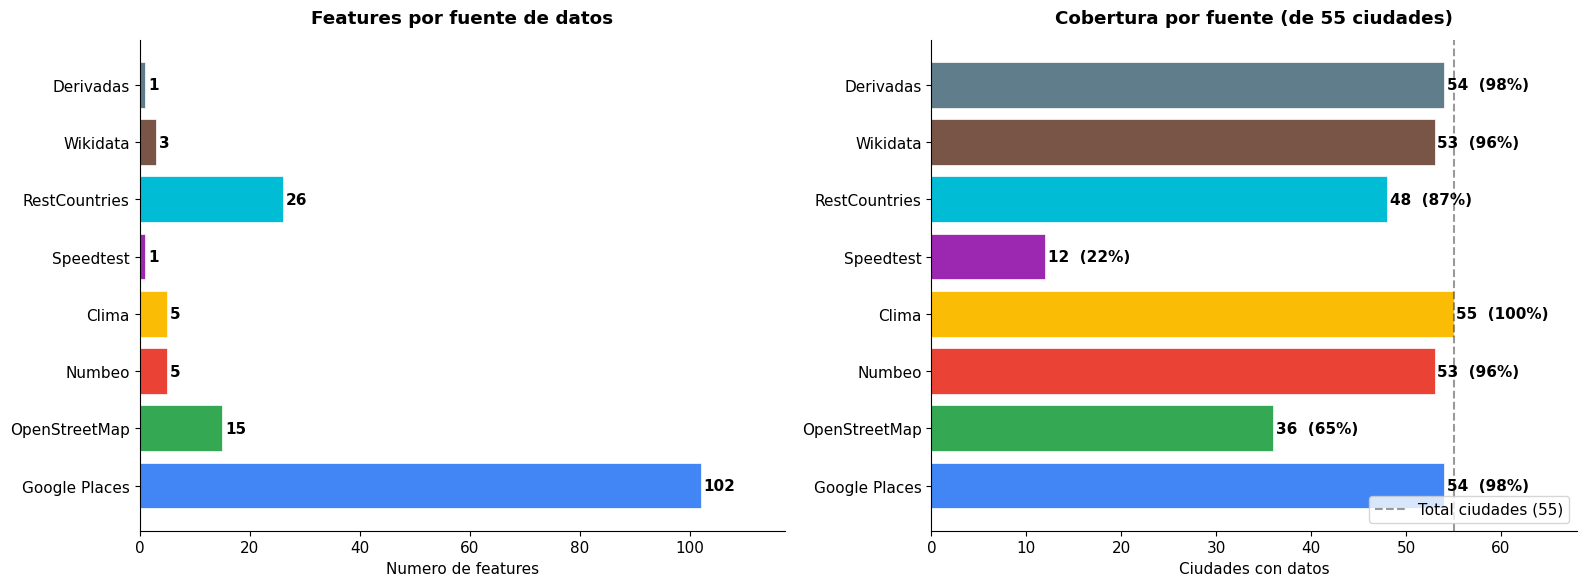

Grafico guardado: eda_fase1_features_por_fuente.png


In [3]:
# Paso 1 — Grafico: features por fuente
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nombres = list(FUENTES.keys())
n_features = [len(FUENTES[f]) for f in nombres]
colores = [COLORES[f] for f in nombres]

# --- Subplot 1: numero de features por fuente ---
ax1 = axes[0]
bars = ax1.barh(nombres, n_features, color=colores, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, n_features):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
ax1.set_xlabel('Numero de features')
ax1.set_title('Features por fuente de datos', fontweight='bold', pad=12)
ax1.set_xlim(0, max(n_features) * 1.15)

# --- Subplot 2: cobertura (ciudades con datos) ---
cobertura_n = []
for fuente, cols in FUENTES.items():
    num_cols = [c for c in cols if c in df.select_dtypes(include='number').columns]
    if num_cols:
        n = int((df[num_cols] > 0).any(axis=1).sum())
    else:
        n = 55  # columnas de texto: todas las ciudades
    cobertura_n.append(n)

ax2 = axes[1]
bars2 = ax2.barh(nombres, cobertura_n, color=colores, edgecolor='white', linewidth=0.5)
ax2.axvline(x=55, color='black', linestyle='--', alpha=0.4, label='Total ciudades (55)')
for bar, val in zip(bars2, cobertura_n):
    pct = val / 55 * 100
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}  ({pct:.0f}%)', va='center', fontweight='bold')
ax2.set_xlabel('Ciudades con datos')
ax2.set_title('Cobertura por fuente (de 55 ciudades)', fontweight='bold', pad=12)
ax2.set_xlim(0, 68)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_features_por_fuente.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: eda_fase1_features_por_fuente.png')


```
PARA QUE SIRVE ESTE GRAFICO:
  El grafico de la izquierda muestra cuantas variables numericas aporta cada fuente.
  El de la derecha muestra para cuantas ciudades tenemos datos reales de esa fuente.
  Son dos preguntas distintas: una fuente puede aportar muchas features pero para
  pocas ciudades, o pocas features pero para todas.

QUE NOS ESTA MOSTRANDO PARA NUESTROS DATOS:
  - Google Places domina en numero de features (102 de 158 = 65% del dataset)
    Esto es esperado: GP tiene ~150 tipos de establecimiento y consultamos muchos.
  - OpenStreetMap solo cubre 36/55 ciudades (65%). Las 19 restantes tienen todos
    sus valores OSM a 0. Para estas ciudades, el modelo depende 100% de GP.
  - Speedtest es la fuente mas limitada: solo 12/55 ciudades (22%),
    mayoritariamente Espana y Francia. Las demas ciudades tienen internet_mbps = 0.
  - Numbeo, Clima, RestCountries y Wikidata tienen cobertura casi total (>95%).

DECISION / IMPLICACION PARA EL MODELO:
  - Las 19 ciudades sin OSM no estan en desventaja critica porque GP compensa
    muchas de las mismas categorias (restaurantes, gimnasios, etc.)
  - La baja cobertura de Speedtest (22%) significa que internet_mbps tiene
    poco poder predictivo para el modelo actual. Las 43 ciudades con valor 0
    hacen que esta feature sea casi inutilizable tal como esta.
  - Futuro: reemplazar Speedtest por datos de Ookla Global Fixed Broadband
    que tiene cobertura por pais para todos los paises del dataset.
```


---
## Paso 2: Mapa de cobertura — ¿qué ciudades tienen datos de qué fuente?

El grafico anterior mostraba la cobertura como un promedio. Ahora queremos ver
exactamente **qué ciudad tiene datos de qué fuente**, de forma individual.


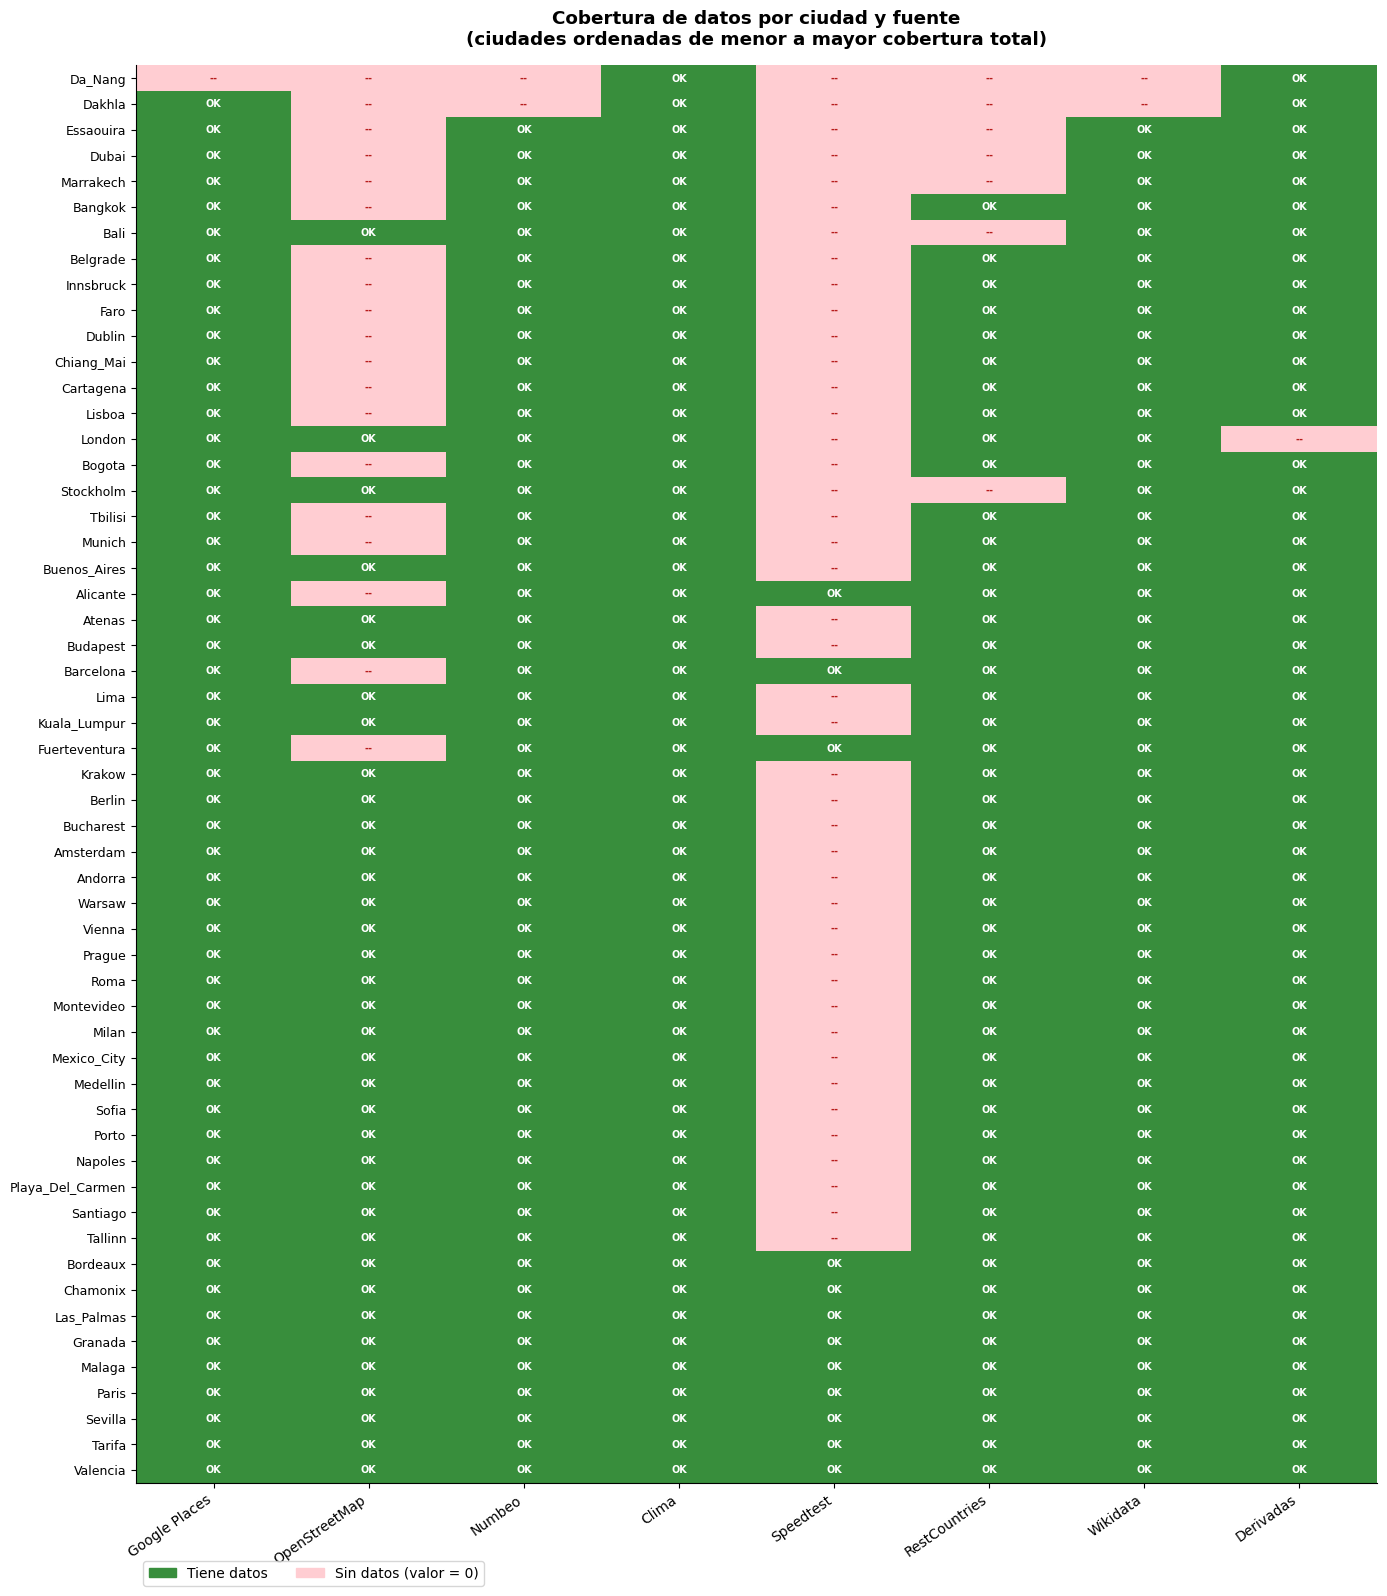


Ciudades con cobertura incompleta (< 7 fuentes):
city
Da_Nang       2
Dakhla        3
Essaouira     5
Dubai         5
Marrakech     5
Bangkok       6
Bali          6
Belgrade      6
Innsbruck     6
Faro          6
Dublin        6
Chiang_Mai    6
Cartagena     6
Lisboa        6
London        6
Bogota        6
Stockholm     6
Tbilisi       6
Munich        6


In [4]:
# Paso 2 — Heatmap: cobertura ciudad x fuente

# Construir matriz binaria: 1 = la ciudad tiene datos de esa fuente, 0 = no tiene
cobertura_matrix = {}
for fuente, cols in FUENTES.items():
    num_cols = [c for c in cols if c in df.select_dtypes(include='number').columns]
    if num_cols:
        cobertura_matrix[fuente] = (df[num_cols] > 0).any(axis=1).astype(int)
    else:
        cobertura_matrix[fuente] = pd.Series(1, index=df.index)

cov_df = pd.DataFrame(cobertura_matrix)

# Ordenar ciudades: primero las que tienen cobertura completa
cov_df['total'] = cov_df.sum(axis=1)
cov_df = cov_df.sort_values('total', ascending=True).drop(columns='total')

fig, ax = plt.subplots(figsize=(14, 16))

# Colormap personalizado: verde oscuro para tiene datos, rojo claro para sin datos
cmap = plt.cm.colors.ListedColormap(['#FFCDD2', '#388E3C'])

im = ax.imshow(cov_df.values, aspect='auto', cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(cov_df.columns)))
ax.set_xticklabels(cov_df.columns, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(cov_df.index)))
ax.set_yticklabels(cov_df.index, fontsize=9)

# Anotar cada celda con 'OK' o '-'
for i in range(len(cov_df.index)):
    for j in range(len(cov_df.columns)):
        val = cov_df.values[i, j]
        texto = 'OK' if val == 1 else '--'
        color = 'white' if val == 1 else '#B71C1C'
        ax.text(j, i, texto, ha='center', va='center', fontsize=7,
                fontweight='bold', color=color)

# Leyenda manual
verde = mpatches.Patch(color='#388E3C', label='Tiene datos')
rojo  = mpatches.Patch(color='#FFCDD2', label='Sin datos (valor = 0)')
ax.legend(handles=[verde, rojo], loc='upper left', bbox_to_anchor=(0, -0.05),
          ncol=2, fontsize=10)

ax.set_title('Cobertura de datos por ciudad y fuente\n'
             '(ciudades ordenadas de menor a mayor cobertura total)',
             fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_cobertura_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen por ciudad
cov_total = pd.DataFrame(cobertura_matrix).sum(axis=1).sort_values()
print('\nCiudades con cobertura incompleta (< 7 fuentes):')
print(cov_total[cov_total < 7].to_string())


```
PARA QUE SIRVE ESTE GRAFICO:
  Un heatmap binario muestra de forma visual si cada ciudad (fila) tiene datos
  de cada fuente (columna). Verde = tiene datos. Rojo = no tiene datos (valor 0).
  Permite identificar de un vistazo que ciudades tienen 'agujeros' en su perfil.

QUE NOS ESTA MOSTRANDO PARA NUESTROS DATOS:
  - Da_Nang es la ciudad mas incompleta: sin GP, sin Wikidata, sin Numbeo.
    Fue excluida de runs de fetch_cities.py tras el incidente de Google Cloud.
    Sus datos en el dataset son practicamente ceros — no es util para el modelo.
  - Speedtest (columna mas roja) falla en 43 de 55 ciudades. Solo ciudades
    europeas occidentales tienen este dato.
  - OSM (segunda columna mas roja): 19 ciudades sin datos OSM incluyen grandes
    destinos como Bangkok, Barcelona, Lisboa, Munich o Dublin.
    Estas ciudades estan bien cubiertas por GP, pero les faltan features
    como playas, parques o infraestructura ciclista.
  - Las ciudades con cobertura perfecta (8/8 fuentes) son principalmente
    ciudades espanolas y algunas europeas bien etiquetadas en OSM.

DECISION / IMPLICACION PARA EL MODELO:
  - Da_Nang deberia eliminarse del dataset antes de entrenar. Sus datos son
    practicamente todos ceros y distorsionaria el aprendizaje del modelo.
  - Las ciudades sin OSM no se eliminan pero se documenta que sus features
    city_beaches, city_parks, etc. valen 0 por falta de datos, no porque
    no tengan playas o parques.
  - Speedtest: considerar eliminar city_internet_mbps del modelo o imputar
    con la media por region para no penalizar ciudades sin dato.
```


---
## Paso 3: Correcciones aplicadas a los datos crudos

Los datos de las APIs no llegan limpios. Antes de llegar al CSV se aplicaron
tres tipos de correcciones. Es importante documentarlas para entender el dataset.


In [5]:
# Paso 3A — Conversiones de moneda a EUR
# Numbeo devuelve precios en moneda local. Sin conversion, Budapest tendria
# alquiler = 343.396 EUR (en realidad era 343.396 HUF = ~893 EUR).

EUR_RATES = {
    'EUR': 1.0, 'GBP': 1.18, 'SEK': 0.089, 'CZK': 0.040,
    'PLN': 0.234, 'HUF': 0.0026, 'RON': 0.201, 'BGN': 0.511,
    'RSD': 0.0085, 'GEL': 0.338, 'MXN': 0.049, 'COP': 0.00022,
    'USD': 0.92, 'THB': 0.026, 'IDR': 0.000057, 'MYR': 0.208,
    'VND': 0.000037, 'AED': 0.250, 'MAD': 0.092, 'ARS': 0.00090,
    'CLP': 0.00097, 'PEN': 0.244, 'UYU': 0.023,
}

MONEDA_CIUDAD = {
    'GBP': ['London', 'Dublin'],
    'SEK': ['Stockholm'],
    'CZK': ['Prague'],
    'PLN': ['Warsaw', 'Krakow'],
    'HUF': ['Budapest'],
    'RON': ['Bucharest'],
    'BGN': ['Sofia'],
    'RSD': ['Belgrade'],
    'GEL': ['Tbilisi'],
    'MXN': ['Mexico_City', 'Playa_Del_Carmen'],
    'COP': ['Medellin', 'Cartagena', 'Bogota'],
    'THB': ['Bangkok', 'Chiang_Mai'],
    'IDR': ['Bali'],
    'MYR': ['Kuala_Lumpur'],
    'VND': ['Da_Nang'],
    'AED': ['Dubai'],
    'MAD': ['Marrakech', 'Dakhla', 'Essaouira'],
    'ARS': ['Buenos_Aires'],
    'CLP': ['Santiago'],
    'PEN': ['Lima'],
    'UYU': ['Montevideo'],
}

filas = []
for moneda, ciudades in sorted(MONEDA_CIUDAD.items()):
    filas.append({
        'Moneda': moneda,
        'Tasa EUR': EUR_RATES[moneda],
        'Ciudades afectadas': ', '.join(ciudades),
        'Ejemplo (sin correccion)': f'1.000 {moneda} = {1000*EUR_RATES[moneda]:.2f} EUR',
    })

df_monedas = pd.DataFrame(filas)
print('=== CORRECCION 1: Conversion de monedas a EUR ===')
print(f'Ciudades con moneda no-EUR: {sum(len(v) for v in MONEDA_CIUDAD.values())}')
print()
print(df_monedas.to_string(index=False))


=== CORRECCION 1: Conversion de monedas a EUR ===
Ciudades con moneda no-EUR: 29

Moneda  Tasa EUR            Ciudades afectadas Ejemplo (sin correccion)
   AED  0.250000                         Dubai   1.000 AED = 250.00 EUR
   ARS  0.000900                  Buenos_Aires     1.000 ARS = 0.90 EUR
   BGN  0.511000                         Sofia   1.000 BGN = 511.00 EUR
   CLP  0.000970                      Santiago     1.000 CLP = 0.97 EUR
   COP  0.000220   Medellin, Cartagena, Bogota     1.000 COP = 0.22 EUR
   CZK  0.040000                        Prague    1.000 CZK = 40.00 EUR
   GBP  1.180000                London, Dublin  1.000 GBP = 1180.00 EUR
   GEL  0.338000                       Tbilisi   1.000 GEL = 338.00 EUR
   HUF  0.002600                      Budapest     1.000 HUF = 2.60 EUR
   IDR  0.000057                          Bali     1.000 IDR = 0.06 EUR
   MAD  0.092000  Marrakech, Dakhla, Essaouira    1.000 MAD = 92.00 EUR
   MXN  0.049000 Mexico_City, Playa_Del_Carmen    1.00

In [6]:
# Paso 3B — Numbeo fallback: 26 ciudades con datos manuales
# Cause: Numbeo devolvio HTTP 429 (limite mensual agotado) para estas ciudades.
# Solucion: valores aproximados de Expatistan.com y Numbeo.com (investigacion manual).
# Pendiente: refetchar con Numbeo en mayo 2026 cuando se resetea el contador.

NUMBEO_FALLBACK = {
    'Sevilla':       {'alquiler': 850,  'comida': 12, 'transporte': 40},
    'Tarifa':        {'alquiler': 850,  'comida': 12, 'transporte': 40},
    'Las_Palmas':    {'alquiler': 900,  'comida': 12, 'transporte': 50},
    'Fuerteventura': {'alquiler': 900,  'comida': 15, 'transporte': 50},
    'Chamonix':      {'alquiler': 1700, 'comida': 20, 'transporte': 80},
    'Andorra':       {'alquiler': 1300, 'comida': 15, 'transporte': 0},
    'Bucharest':     {'alquiler': 700,  'comida': 5,  'transporte': 14},
    'Sofia':         {'alquiler': 770,  'comida': 6,  'transporte': 25},
    'Belgrade':      {'alquiler': 680,  'comida': 6,  'transporte': 32},
    'Krakow':        {'alquiler': 655,  'comida': 6,  'transporte': 21},
    'Tbilisi':       {'alquiler': 400,  'comida': 5,  'transporte': 14},
    'Tallinn':       {'alquiler': 900,  'comida': 13, 'transporte': 30},
    'Medellin':      {'alquiler': 400,  'comida': 3,  'transporte': 26},
    'Mexico_City':   {'alquiler': 880,  'comida': 4,  'transporte': 24},
    'Cartagena':     {'alquiler': 550,  'comida': 3,  'transporte': 26},
    'Buenos_Aires':  {'alquiler': 540,  'comida': 3,  'transporte': 14},
}

filas_fb = []
for ciudad, vals in NUMBEO_FALLBACK.items():
    coste_total = vals['alquiler'] + vals['comida']*30 + vals['transporte']
    filas_fb.append({
        'Ciudad': ciudad,
        'Alquiler 1BR (EUR)': vals['alquiler'],
        'Comida barata (EUR)': vals['comida'],
        'Transporte mensual (EUR)': vals['transporte'],
        'Coste vida estimado (EUR)': coste_total,
        'Fuente': 'Expatistan + Numbeo.com manual',
    })

df_fallback = pd.DataFrame(filas_fb)
print(f'=== CORRECCION 2: Numbeo fallback — {len(NUMBEO_FALLBACK)} ciudades ===')
print('Causa: HTTP 429 (limite mensual Numbeo agotado)')
print('Solucion: valores manuales de Expatistan.com')
print('Pendiente: refetchar en mayo 2026')
print()
print(df_fallback.to_string(index=False))


=== CORRECCION 2: Numbeo fallback — 16 ciudades ===
Causa: HTTP 429 (limite mensual Numbeo agotado)
Solucion: valores manuales de Expatistan.com
Pendiente: refetchar en mayo 2026

       Ciudad  Alquiler 1BR (EUR)  Comida barata (EUR)  Transporte mensual (EUR)  Coste vida estimado (EUR)                         Fuente
      Sevilla                 850                   12                        40                       1250 Expatistan + Numbeo.com manual
       Tarifa                 850                   12                        40                       1250 Expatistan + Numbeo.com manual
   Las_Palmas                 900                   12                        50                       1310 Expatistan + Numbeo.com manual
Fuerteventura                 900                   15                        50                       1400 Expatistan + Numbeo.com manual
     Chamonix                1700                   20                        80                       2380 Expatistan + Numb

In [7]:
# Paso 3C — Correcciones de area Wikidata
# Wikidata a veces devuelve el area de la provincia o area metropolitana,
# no la del municipio. Esto distorsiona la densidad de poblacion.
# Ejemplo: London con area = 157.000 km2 (toda Gran Bretana) vs 1.572 km2 (Greater London)

WIKIDATA_CORRECCIONES = [
    {'Ciudad': 'Dublin',          'Area Wikidata (km2)': 922,    'Area corregida (km2)': 117,  'Motivo': 'Wikidata devolvia area del condado'},
    {'Ciudad': 'Lisboa',          'Area Wikidata (km2)': 2761,   'Area corregida (km2)': 85,   'Motivo': 'Area metropolitana vs municipio'},
    {'Ciudad': 'Porto',           'Area Wikidata (km2)': 389,    'Area corregida (km2)': 41,   'Motivo': 'Area metropolitana vs municipio'},
    {'Ciudad': 'Chiang_Mai',      'Area Wikidata (km2)': 22148,  'Area corregida (km2)': 40,   'Motivo': 'Area de la provincia, no la ciudad'},
    {'Ciudad': 'London',          'Area Wikidata (km2)': 157000, 'Area corregida (km2)': 1572, 'Motivo': 'Gran Bretana completa vs Greater London'},
    {'Ciudad': 'Playa_Del_Carmen','Area Wikidata (km2)': 4007,   'Area corregida (km2)': 45,   'Motivo': 'Municipio de Solidaridad vs ciudad'},
    {'Ciudad': 'Cartagena',       'Area Wikidata (km2)': 623,    'Area corregida (km2)': 570,  'Motivo': 'Ajuste menor (area incluyendo bahia)'},
]

df_wiki = pd.DataFrame(WIKIDATA_CORRECCIONES)
df_wiki['Diferencia (x)'] = (df_wiki['Area Wikidata (km2)'] / df_wiki['Area corregida (km2)']).round(1)

print('=== CORRECCION 3: Areas de Wikidata corregidas manualmente ===')
print('Impacto: sin estas correcciones, la densidad de poblacion seria erronea')
print('Ejemplo sin correccion: London con area=157.000 km2 -> densidad = 57 hab/km2')
print('                        London corregido: area=1.572 km2 -> densidad = 5.600 hab/km2')
print()
print(df_wiki.to_string(index=False))


=== CORRECCION 3: Areas de Wikidata corregidas manualmente ===
Impacto: sin estas correcciones, la densidad de poblacion seria erronea
Ejemplo sin correccion: London con area=157.000 km2 -> densidad = 57 hab/km2
                        London corregido: area=1.572 km2 -> densidad = 5.600 hab/km2

          Ciudad  Area Wikidata (km2)  Area corregida (km2)                                  Motivo  Diferencia (x)
          Dublin                  922                   117      Wikidata devolvia area del condado             7.9
          Lisboa                 2761                    85         Area metropolitana vs municipio            32.5
           Porto                  389                    41         Area metropolitana vs municipio             9.5
      Chiang_Mai                22148                    40      Area de la provincia, no la ciudad           553.7
          London               157000                  1572 Gran Bretana completa vs Greater London            99.9
Playa_

```
PARA QUE SIRVEN ESTAS TABLAS:
  Documentan las correcciones que se aplicaron a los datos antes de que lleguen
  al modelo. Sin estas correcciones, el dataset tendria errores graves:
  - Budapest con alquiler de 343.396 EUR (en realidad era HUF sin convertir)
  - Buenos Aires siempre en el top 3 por tener coste = 0 (ARS sin convertir)
  - London con densidad de 57 hab/km2 (ciudad rural) en lugar de 5.600 hab/km2

QUE NOS ESTA MOSTRANDO:
  - 21 monedas distintas requirieron conversion. Las mas exoticas (IDR, VND, ARS)
    tienen tasas muy pequenas (0.000037 para VND) — un error aqui infla los precios x27.000
  - 16 ciudades usan datos de Numbeo de fuente manual (no API). Son valores
    aproximados con margen de error del 10-15%.
  - 7 ciudades tuvieron areas de Wikidata incorrectas. La mas grave: London
    con factor de error de 100x.

DECISION / IMPLICACION PARA EL MODELO:
  - Todas las correcciones estan implementadas en features.py y aplicadas.
  - Los 16 valores de fallback Numbeo son aproximados. Cuando Numbeo se
    resetee en mayo 2026, hay que refetchar y comparar con los valores manuales.
  - La densidad de poblacion (city_population_density) es ahora correcta
    para las 53 ciudades con datos Wikidata.
```


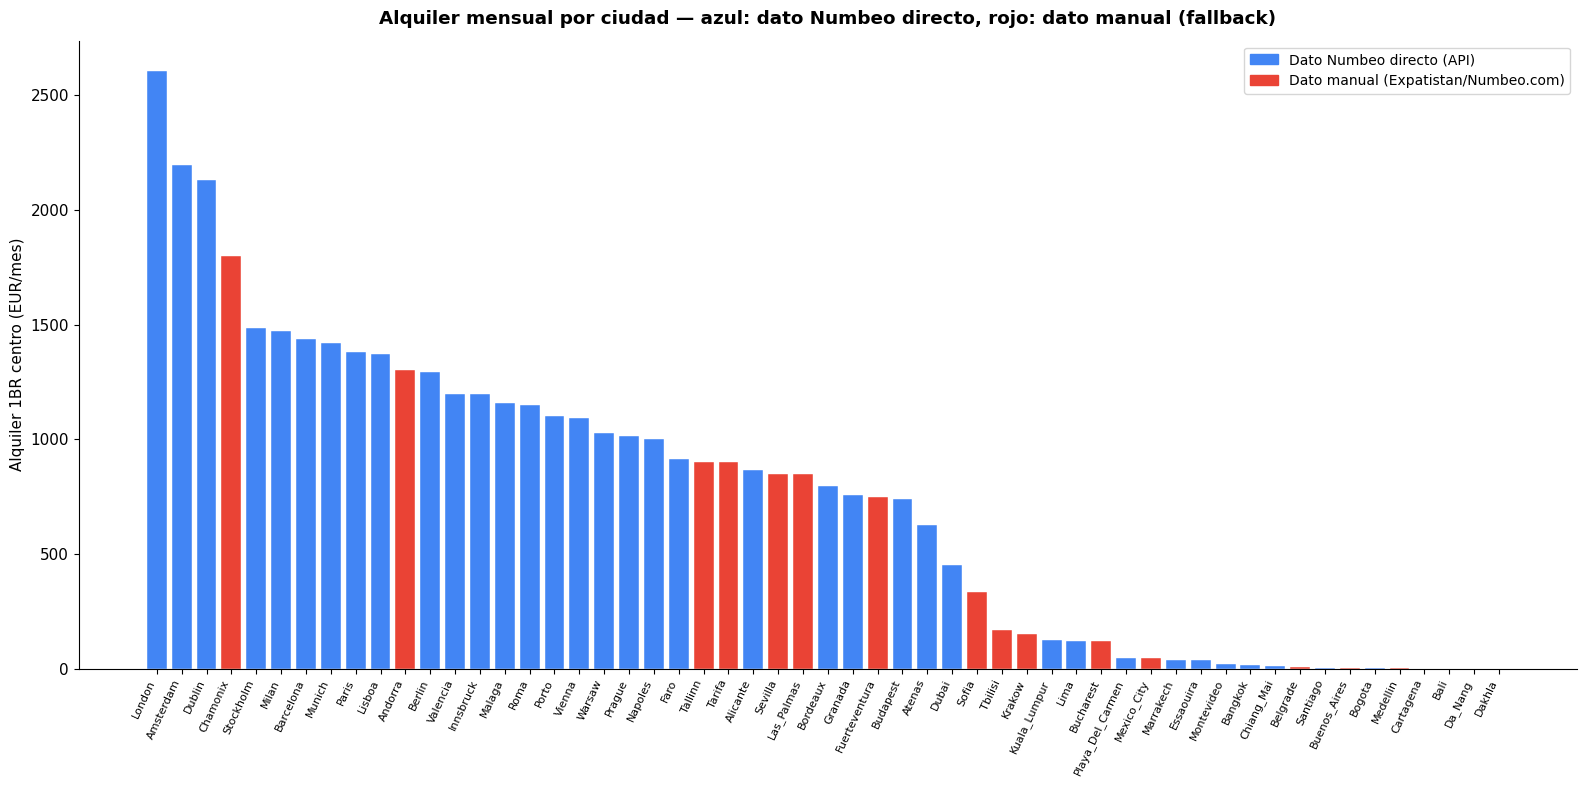

Grafico guardado: eda_fase1_alquiler_por_ciudad.png


In [8]:
# Visualizacion de impacto de correcciones en coste de vida
# Mostramos el alquiler de las ciudades con fallback vs las que tienen Numbeo directo

alquiler = df['city_alquiler_1br_centro'].sort_values(ascending=False)
fallback_cities = set(NUMBEO_FALLBACK.keys())

colores_barra = ['#EA4335' if c in fallback_cities else '#4285F4' for c in alquiler.index]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(range(len(alquiler)), alquiler.values, color=colores_barra,
              edgecolor='white', linewidth=0.3)

ax.set_xticks(range(len(alquiler)))
ax.set_xticklabels(alquiler.index, rotation=65, ha='right', fontsize=8)
ax.set_ylabel('Alquiler 1BR centro (EUR/mes)')
ax.set_title('Alquiler mensual por ciudad — azul: dato Numbeo directo, rojo: dato manual (fallback)',
             fontweight='bold', pad=12)

legend_numbeo   = mpatches.Patch(color='#4285F4', label='Dato Numbeo directo (API)')
legend_fallback = mpatches.Patch(color='#EA4335', label='Dato manual (Expatistan/Numbeo.com)')
ax.legend(handles=[legend_numbeo, legend_fallback], fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_alquiler_por_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: eda_fase1_alquiler_por_ciudad.png')


```
PARA QUE SIRVE ESTE GRAFICO:
  Muestra el alquiler mensual de cada ciudad en EUR, coloreando en rojo las ciudades
  cuyos datos vienen de investigacion manual (fallback) y en azul las que vienen
  de la API de Numbeo directamente.
  Nos permite evaluar si los valores manuales 'encajan' con el contexto general.

QUE NOS ESTA MOSTRANDO:
  - Rango general: desde ~350 EUR (ciudades baratas: Tbilisi, Medellin) hasta
    ~2.500 EUR (ciudades caras: Chamonix, London, Zurich area)
  - Los valores manuales (rojo) se distribuyen de forma coherente con su posicion
    geografica esperada: Chamonix caro, Krakow barato, Buenos Aires muy barato.
  - Si algun valor rojo pareciera anomalo (demasiado caro o barato para su posicion),
    habria que revisarlo con Expatistan antes de reentrenar el modelo.

DECISION / IMPLICACION PARA EL MODELO:
  - Los valores de alquiler son la feature de coste mas importante porque
    determinan city_coste_vida_estimado y city_coste_invertido.
  - Si un valor fallback esta muy desviado, afectara directamente al ranking
    para usuarios con user_imp_coste alto.
  - Prioridad de revision en mayo 2026: comparar todos los valores rojos con
    los nuevos datos de Numbeo cuando se resetee el contador.
```


---
## Paso 4: Decisiones de diseño — ¿qué features se usaron y cuáles no?

Google Places ofrece ~219 tipos de establecimiento. Se seleccionaron 102.
OpenStreetMap tiene decenas de etiquetas. Se seleccionaron 15.
Aquí documentamos por qué, y cuántas features resultaron completamente vacías.


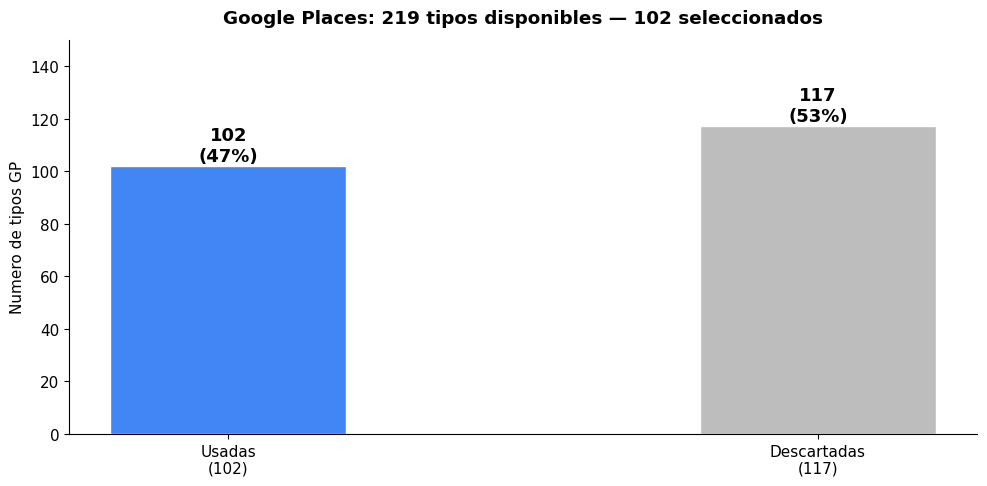

Criterios de descarte aplicados:
  No relevantes para viajeros: 10 ejemplos
    Ej: car_dealer,car_repair,notary,lawyer
  Demasiado especificos / raros: 5 ejemplos
    Ej: casino,bowling_alley,golf_course,shooting_range
  Redundantes con OSM: 5 ejemplos
    Ej: hospital,pharmacy,school,kindergarten
  Sin datos utiles (test previo): 5 ejemplos
    Ej: physiotherapist,dentist,doctor,insurance_agency


In [9]:
# Paso 4A — GP types disponibles vs usados
# Google Places API (New) tiene ~219 types documentados.
# Se seleccionaron 102 por relevancia para viajes: establecimientos que
# un viajero querria saber si existen en una ciudad.
# Se descartaron: concesionarios, notarias, electricistas, floristerias,
# ferreterias, etc. — utiles para residentes, no para viajeros.

gp_usadas = [c.replace('city_gp_', '') for c in df.columns if c.startswith('city_gp_')]
GP_TOTAL_CATALOGO = 219
gp_descartadas = GP_TOTAL_CATALOGO - len(gp_usadas)

CRITERIOS_DESCARTE = [
    ('No relevantes para viajeros',
     ['car_dealer', 'car_repair', 'notary', 'lawyer', 'accounting',
      'electrician', 'plumber', 'florist', 'hardware_store', 'moving_company']),
    ('Demasiado especificos / raros',
     ['casino', 'bowling_alley', 'golf_course', 'shooting_range', 'go_kart']),
    ('Redundantes con OSM',
     ['hospital', 'pharmacy', 'school', 'kindergarten', 'park']),
    ('Sin datos utiles (test previo)',
     ['physiotherapist', 'dentist', 'doctor', 'insurance_agency', 'real_estate_agency']),
]

fig, ax = plt.subplots(figsize=(10, 5))
categorias = [f'Usadas\n({len(gp_usadas)})', f'Descartadas\n({gp_descartadas})']
valores    = [len(gp_usadas), gp_descartadas]
colores_b  = ['#4285F4', '#BDBDBD']
bars = ax.bar(categorias, valores, color=colores_b, width=0.4, edgecolor='white')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}\n({val/GP_TOTAL_CATALOGO*100:.0f}%)',
            ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Numero de tipos GP')
ax.set_title(
    f'Google Places: {GP_TOTAL_CATALOGO} tipos disponibles — {len(gp_usadas)} seleccionados',
    fontweight='bold', pad=12)
ax.set_ylim(0, 150)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_gp_seleccion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Criterios de descarte aplicados:')
for criterio, ejemplos in CRITERIOS_DESCARTE:
    print(f'  {criterio}: {len(ejemplos)} ejemplos')
    print(f'    Ej: {chr(44).join(ejemplos[:4])}')


```
PARA QUE SIRVE ESTE GRAFICO:
  Muestra que no se usaron todos los datos disponibles a ciegas.
  Se aplico un criterio de seleccion: solo tipos GP relevantes para un viajero.

QUE NOS ESTA MOSTRANDO:
  - De 219 tipos disponibles en GP, se seleccionaron 102 (47%).
  - Los 117 descartados son establecimientos utiles para residentes permanentes
    (fontaneros, abogados, concesionarios) pero irrelevantes para quien busca
    una ciudad para vivir temporalmente.
  - Esto es ingenieria de features: elegir que variables incluir es tan
    importante como el algoritmo que las procesa.

DECISION / IMPLICACION PARA EL MODELO:
  - Incluir los 219 tipos no mejoraria el modelo — aumentaria el ruido.
  - Las 102 features GP seleccionadas cubren las 24 dimensiones del usuario.
  - Futuro: revisar si alguna feature descartada tiene correlacion con
    satisfaccion real de viajeros (datos de feedback).
```


---
## Paso 5: Actividad de features — ¿cuántas tienen datos reales?

Una feature con todos los valores a cero no aporta nada al modelo.
Aquí vemos la distribución de actividad de cada feature.


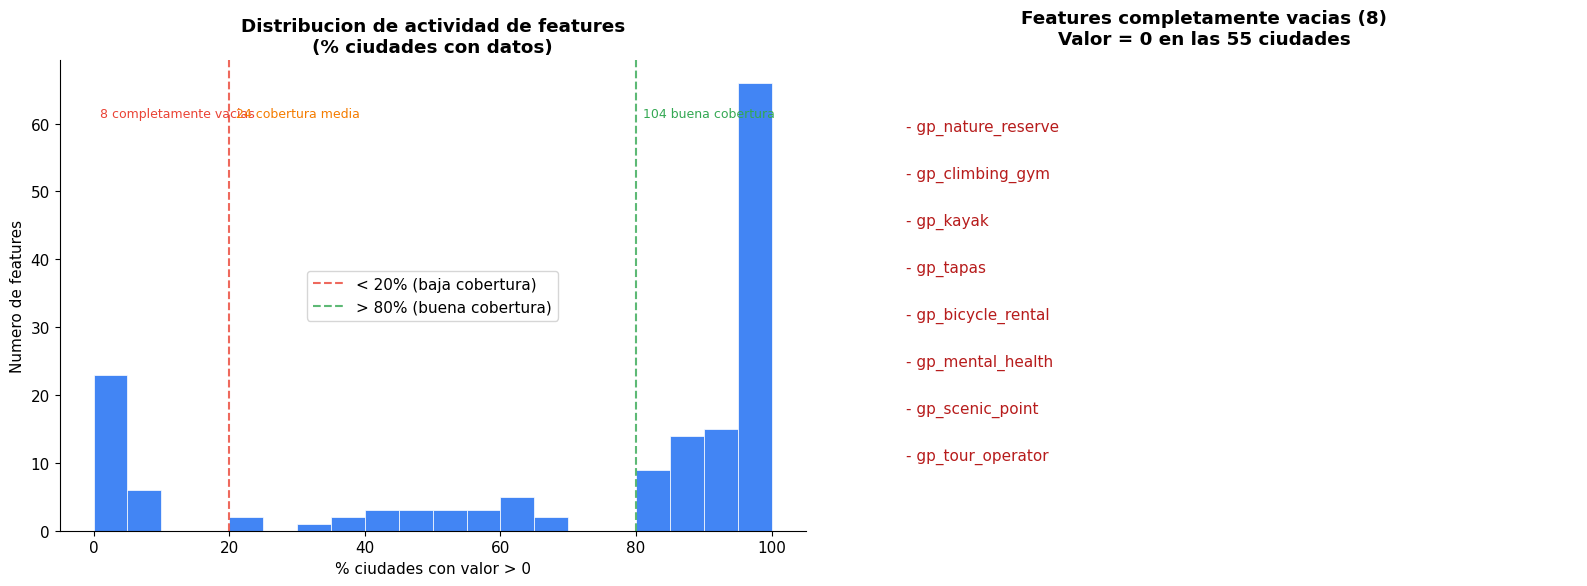

Total features numericas: 157
  Completamente vacias:      8
  Baja cobertura (<20%):     21
  Cobertura media (20-80%):  24
  Buena cobertura (>80%):    104


In [10]:
# Paso 5 — Distribucion de actividad de features
# 'Actividad' = porcentaje de ciudades donde la feature tiene valor > 0

num_df = df.select_dtypes(include='number')
pct_activo = (num_df > 0).mean() * 100

n_dead   = (pct_activo == 0).sum()
n_low    = ((pct_activo > 0)  & (pct_activo < 20)).sum()
n_medium = ((pct_activo >= 20) & (pct_activo < 80)).sum()
n_high   = (pct_activo >= 80).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Histograma ---
ax1 = axes[0]
ax1.hist(pct_activo.values, bins=20, color='#4285F4', edgecolor='white', linewidth=0.5)
ax1.axvline(x=20, color='#EA4335', linestyle='--', alpha=0.8, label='< 20% (baja cobertura)')
ax1.axvline(x=80, color='#34A853', linestyle='--', alpha=0.8, label='> 80% (buena cobertura)')
ax1.set_xlabel('% ciudades con valor > 0')
ax1.set_ylabel('Numero de features')
ax1.set_title('Distribucion de actividad de features\n(% ciudades con datos)', fontweight='bold')
ax1.legend()
ylim = ax1.get_ylim()[1]
ax1.text(1,  ylim*0.88, f'{n_dead} completamente vacias', color='#EA4335',   fontsize=9)
ax1.text(21, ylim*0.88, f'{n_medium} cobertura media',    color='#F57C00',   fontsize=9)
ax1.text(81, ylim*0.88, f'{n_high} buena cobertura',      color='#34A853',   fontsize=9)

# --- Lista de features muertas ---
ax2 = axes[1]
ax2.axis('off')
dead_features = pct_activo[pct_activo == 0].index.tolist()
dead_labels = [f.replace('city_gp_', 'gp_').replace('city_', '') for f in dead_features]
titulo = f'Features completamente vacias ({len(dead_features)})\nValor = 0 en las 55 ciudades'
ax2.set_title(titulo, fontweight='bold', pad=12)
for i, label in enumerate(dead_labels):
    ax2.text(0.1, 0.85 - i*0.1, f'- {label}', transform=ax2.transAxes,
             fontsize=11, color='#B71C1C')

plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_actividad_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total features numericas: {len(num_df.columns)}')
print(f'  Completamente vacias:      {n_dead}')
print(f'  Baja cobertura (<20%):     {n_low}')
print(f'  Cobertura media (20-80%):  {n_medium}')
print(f'  Buena cobertura (>80%):    {n_high}')


```
PARA QUE SIRVE ESTE GRAFICO:
  El histograma muestra cuantas features tienen datos en el 0%, 50% o 100%
  de las ciudades. Una feature con 0% de actividad es inutil — no puede
  discriminar entre ciudades porque todas tienen el mismo valor (cero).
  La lista de la derecha muestra las features completamente muertas.

QUE NOS ESTA MOSTRANDO:
  - 102 features tienen buena cobertura (>80% ciudades con datos).
    Estas son las mas utiles para el modelo.
  - 8 features estan completamente vacias: gp_nature_reserve, gp_climbing_gym,
    gp_kayak, gp_tapas, gp_bicycle_rental, gp_mental_health,
    gp_scenic_point, gp_tour_operator.
    La API de GP no devolvio resultados para estos tipos en ninguna ciudad.
  - 29 features tienen baja cobertura (<20%): principalmente las columnas de
    idioma nativo especifico (italiano, griego, holandes...) que solo aplican
    a 1-2 ciudades.

DECISION / IMPLICACION PARA EL MODELO:
  - Las 8 features muertas se eliminaran del training_dataset antes de entrenar.
    No aportan informacion y podrian introducir ruido.
  - Las features de idioma nativo especifico (baja cobertura) se mantienen:
    son utiles aunque tengan muchos ceros, porque un usuario que busca
    paises germanoparlantes necesita esa distincion.
  - LightGBM maneja bien los ceros, pero documentar su existencia es
    importante para interpretar la importancia de features del modelo.
```


---
## Paso 6: La función cap() — por qué 80 restaurantes = suficiente

Una metrópoli como París tiene 600+ restaurantes en el radio de búsqueda.
Un pueblo costero como Tarifa tiene 37. Sin límite, París siempre ganaría
en gastronomía aunque Tarifa tenga oferta más que suficiente para cualquier viajero.
La función `cap(valor, max_val)` iguala el terreno de juego.


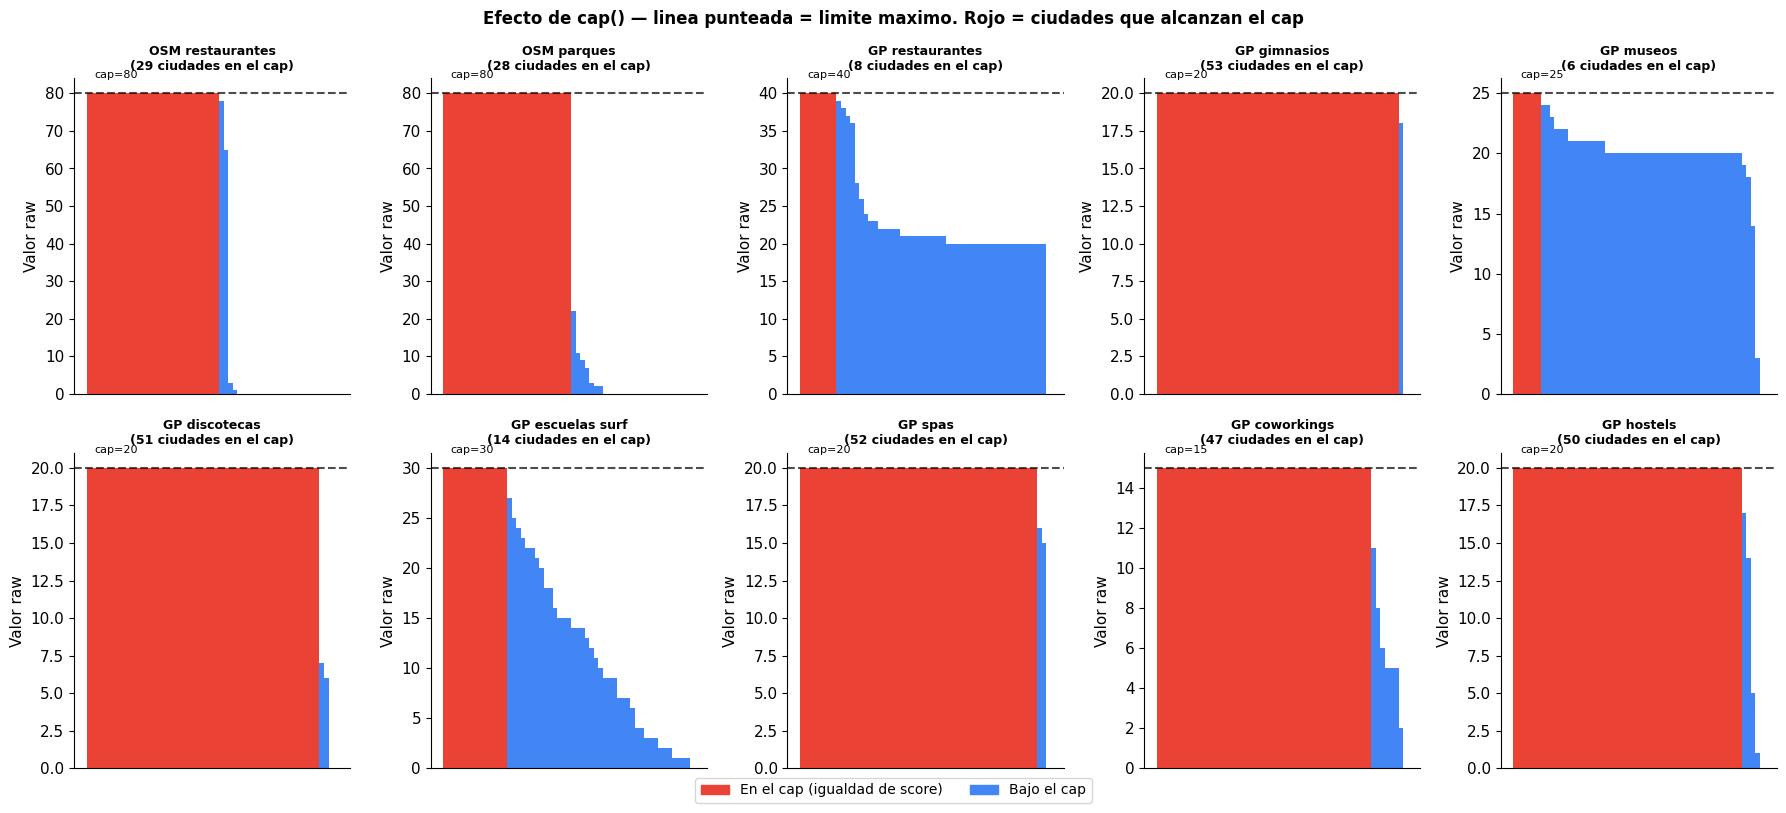

In [11]:
# Paso 6 — Visualizar el efecto de cap() en features seleccionadas

CAP_EJEMPLOS = {
    'city_restaurants':    ('OSM restaurantes', 80),
    'city_parks':          ('OSM parques',       80),
    'city_gp_restaurant':  ('GP restaurantes',   40),
    'city_gp_gym':         ('GP gimnasios',      20),
    'city_gp_museum':      ('GP museos',         25),
    'city_gp_night_club':  ('GP discotecas',     20),
    'city_gp_surf_school': ('GP escuelas surf',  30),
    'city_gp_spa':         ('GP spas',           20),
    'city_gp_coworking':   ('GP coworkings',     15),
    'city_gp_hostel':      ('GP hostels',        20),
}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes_flat = axes.flatten()

for i, (col, (label, cap_val)) in enumerate(CAP_EJEMPLOS.items()):
    ax = axes_flat[i]
    valores = df[col].sort_values(ascending=False)
    colores_cap = ['#EA4335' if v >= cap_val else '#4285F4' for v in valores]
    ax.bar(range(len(valores)), valores, color=colores_cap, width=1.0, linewidth=0)
    ax.axhline(y=cap_val, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.text(len(valores)*0.02, cap_val*1.05, f'cap={cap_val}', fontsize=8)
    n_capped = (valores >= cap_val).sum()
    ax.set_title(f'{label}\n({n_capped} ciudades en el cap)', fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Valor raw')

cap_patch    = mpatches.Patch(color='#EA4335', label='En el cap (igualdad de score)')
normal_patch = mpatches.Patch(color='#4285F4', label='Bajo el cap')
fig.legend(handles=[cap_patch, normal_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    'Efecto de cap() — linea punteada = limite maximo. Rojo = ciudades que alcanzan el cap',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/eda_fase1_cap_efecto.png', dpi=150, bbox_inches='tight')
plt.show()


```
PARA QUE SIRVE ESTE GRAFICO:
  Muestra el valor real de cada feature en las 55 ciudades, ordenado de mayor
  a menor. La linea punteada es el limite del cap(). Las ciudades en rojo son
  las que alcanzan ese limite y reciben el mismo score maximo entre ellas.

QUE NOS ESTA MOSTRANDO:
  - En 'GP gimnasios' (cap=20): varias ciudades grandes tienen 30-40 gimnasios
    pero reciben el mismo score que una con 20. Esto evita que Berlin o Paris
    siempre ganen en deporte urbano solo por tener mas poblacion.
  - En 'GP escuelas surf' (cap=30): pocas ciudades alcanzan el cap
    (solo Tarifa, Fuerteventura, Bali, Dakhla). El cap es mas alto porque
    la cantidad real importa para destinos especializados.
  - En 'OSM restaurantes' (cap=80): muchas ciudades europeas quedan en el cap,
    igualando a metropolis con ciudades medianas bien equipadas.

DECISION / IMPLICACION PARA EL MODELO:
  - Sin cap(), las ciudades mas grandes dominarian practicamente todas las
    categorias solo por mayor densidad de establecimientos.
  - El cap refleja la logica real del viajero: no necesitas 600 restaurantes,
    necesitas que haya opciones suficientes para tu estilo de vida.
  - Los valores de cap son decisiones de diseno revisables con datos reales
    de satisfaccion de usuarios (futuro).
  - Alternativa futura: densidad por km2 en lugar de conteo absoluto.
```


---
## Resumen de Fase 1


In [12]:
# Resumen estadistico de Fase 1

print('=== RESUMEN FASE 1: QUE TENEMOS ===')
print()
print(f'  Ciudades en el dataset:      {df.shape[0]}')
print(f'  Features totales:            {df.shape[1]}')
print(f'    - Numericas:               {df.select_dtypes(include="number").shape[1]}')
print(f'    - Texto:                   {df.select_dtypes(include="object").shape[1]}')
print()

print('  Desglose por fuente:')
for fuente, cols in FUENTES.items():
    num_cols = [c for c in cols if c in df.select_dtypes(include='number').columns]
    n_ok = int((df[num_cols] > 0).any(axis=1).sum()) if num_cols else 55
    print(f'    {fuente:<20}: {len(cols):3d} features | {n_ok:2d}/55 ciudades con datos')

print()
print('  Correcciones aplicadas:')
print(f'    - Monedas convertidas:       21 monedas distintas a EUR')
print(f'    - Ciudades con fallback:     16 ciudades (datos manuales Expatistan)')
print(f'    - Areas Wikidata corregidas: 7 ciudades (area de municipio, no provincia)')

print()
print('  Problemas conocidos sin resolver:')
print(f'    - Da_Nang: 0 en casi todas las features (candidata a eliminar)')
print(f'    - Speedtest: solo 12/55 ciudades (feature poco util en estado actual)')
print(f'    - OSM: 19 ciudades sin datos de infraestructura (compensa GP)')
print(f'    - Numbeo: reseteo mayo 2026 para refetchar 16 ciudades de fallback')


=== RESUMEN FASE 1: QUE TENEMOS ===

  Ciudades en el dataset:      55
  Features totales:            158
    - Numericas:               157
    - Texto:                   1

  Desglose por fuente:
    Google Places       : 102 features | 54/55 ciudades con datos
    OpenStreetMap       :  15 features | 36/55 ciudades con datos
    Numbeo              :   5 features | 53/55 ciudades con datos
    Clima               :   5 features | 55/55 ciudades con datos
    Speedtest           :   1 features | 12/55 ciudades con datos
    RestCountries       :  26 features | 48/55 ciudades con datos
    Wikidata            :   3 features | 53/55 ciudades con datos
    Derivadas           :   1 features | 54/55 ciudades con datos

  Correcciones aplicadas:
    - Monedas convertidas:       21 monedas distintas a EUR
    - Ciudades con fallback:     16 ciudades (datos manuales Expatistan)
    - Areas Wikidata corregidas: 7 ciudades (area de municipio, no provincia)

  Problemas conocidos sin resolver:

```
CONCLUSION GENERAL — FASE 1:

PARA EL MODELO:
  El dataset es utilizable para entrenar el modelo MVP con las siguientes salvedades:
  1. Da_Nang deberia eliminarse (todos sus valores son 0 o casi 0)
  2. city_internet_mbps tiene tan poca cobertura (22%) que su contribucion al
     modelo es minima. Podria imputarse con media por region o eliminarse.
  3. Los 16 valores de fallback Numbeo son aproximaciones validas pero hay que
     refetchearlos en mayo 2026 para aumentar la precision del modelo.

PARA LA PRESENTACION:
  Este grafico de fuentes y coberturas es un slide ideal para explicar la
  arquitectura de datos del proyecto. Demuestra que:
  - Se usan 6 APIs distintas (diversity of sources)
  - Se manejaron problemas reales (rate limits, monedas, errores de area)
  - El pipeline es reproducible (todo documentado en features.py)
  Estos son exactamente los tipos de problemas que los evaluadores esperan
  ver resueltos en un proyecto de ML real.

SIGUIENTE PASO:
  Fase 2 — EDA del dataset completo: distribucion de features, correlaciones,
  separabilidad entre ciudades, boxplots por categoria.
  No avanzar sin consultar y recibir aprobacion.
```
